<h1><b><u>Customer Churn Analysis Prediction<b></h1>


<h2><b>A)Data pre-processing</h2>
<h3><b>1). Importing Libraries</h3> 

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<h3><b>2). Importing & Loading Dataset</h3>

In [4]:
df=pd.read_csv(r"C:\Users\alian\OneDrive\Desktop\Intenship\Netflix_churn_pridiction\netflix_users.csv")
df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


<h3><b>3). Understanding the Dataset</h3>

<h3><b>ii) Checking the rows & columns</h3>

In [5]:
df.shape

(25000, 8)

<h3><b>iii) Checking data types & nulls</h3>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB


<h3><b>iv) Checking statistical summary </h3>

In [7]:
df.describe()

,User_ID,Age,Watch_Time_Hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,46.482880,500.468858
std,7217.022701,19.594861,286.381815
min,1.000000,13.000000,0.120000
25%,6250.750000,29.000000,256.567500
50%,12500.500000,46.000000,501.505000
75%,18750.250000,63.000000,745.732500
max,25000.000000,80.000000,999.990000


<h2><b>4). Data Cleaning</h2>

<h3><b>i) Handle Missing Values(identifying and filling the missings)</h3>

In [8]:
df.isnull().sum()

User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64

<h3><b>ii) Identifying & removing Duplicates</h3>

In [9]:
df.duplicated().sum()

0

<h3><b>iii) Removing unwanted rows</h3>

In [10]:
df=df.drop(columns=['User_ID','Name'])

<h3><b>iii) Converting Last_Login to datetime</h3>

In [11]:
df['Last_Login'] = pd.to_datetime(df['Last_Login'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Age                25000 non-null  int64         
 1   Country            25000 non-null  object        
 2   Subscription_Type  25000 non-null  object        
 3   Watch_Time_Hours   25000 non-null  float64       
 4   Favorite_Genre     25000 non-null  object        
 5   Last_Login         25000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 1.1+ MB


<h3><b>iv) Creating churn feature</h3>

In [17]:
# Make sure Last_Login exists
df['Last_Login'] = pd.to_datetime(df['Last_Login'])

# Calculate Days_Inactive
reference_date = pd.Timestamp('2025-06-01')
df['Days_Inactive'] = (reference_date - df['Last_Login']).dt.days

# Now define Churn
df['Churn'] = ((df['Days_Inactive'] > 180) & (df['Watch_Time_Hours'] < 300)).astype(int)

In [18]:
df.head()

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Days_Inactive,Churn
0,18,France,Premium,80.26,Drama,2024-05-12,385,1
1,23,USA,Premium,321.75,Sci-Fi,2025-02-05,116,0
2,60,UK,Basic,35.89,Comedy,2025-01-24,128,0
3,44,USA,Premium,261.56,Documentary,2024-03-25,433,1
4,68,USA,Standard,909.30,Drama,2025-01-14,138,0


In [19]:
df.drop(['Last_Login','Days_Inactive'], axis=1, inplace=True)

In [20]:
df.shape

(25000, 6)

<h3><b>v) Checking outliers</h3>

In [21]:
Q1 = df['Watch_Time_Hours'].quantile(0.25)
Q3 = df['Watch_Time_Hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Watch_Time_Hours'] < lower) | 
              (df['Watch_Time_Hours'] > upper)]

print(outliers)

Empty DataFrame
Columns: [Age, Country, Subscription_Type, Watch_Time_Hours, Favorite_Genre, Churn]
Index: []


In [22]:
columns_to_check = ['Age', 'Watch_Time_Hours']

for col in columns_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col} → {len(outliers)} outliers")

Age → 0 outliers
Watch_Time_Hours → 0 outliers


In [23]:
df.shape

(25000, 6)

<h2><b> 5). Exploratory Data Analysis (EDA)</h2>

<h3><b>ii) Churn by Subscription Type</h3>

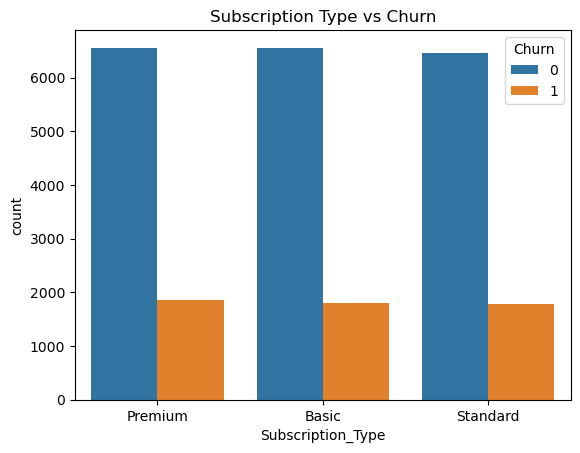

In [24]:
sns.countplot(x='Subscription_Type', hue='Churn', data=df)
plt.title('Subscription Type vs Churn')
plt.show()


<h3><b>iii) Churn by Watch_Time_Hours</h3>

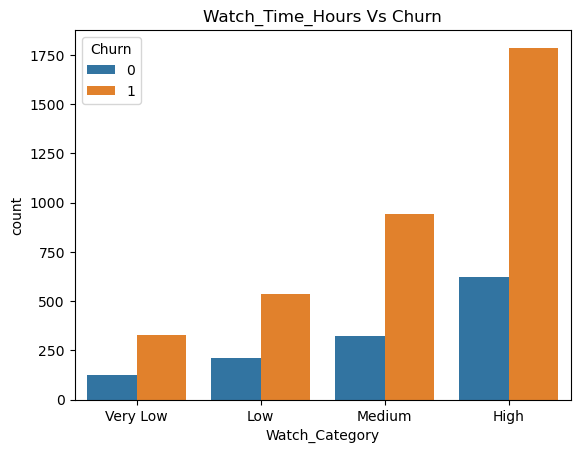

In [25]:
df['Watch_Category'] = pd.cut(
    df['Watch_Time_Hours'],
    bins=[0, 20, 50, 100, 200],
    labels=['Very Low', 'Low', 'Medium', 'High']
)
plt.title("Watch_Time_Hours Vs Churn")
sns.countplot(x='Watch_Category', hue='Churn', data=df)
plt.show()

<h3><b>v) Churn by country</h3>

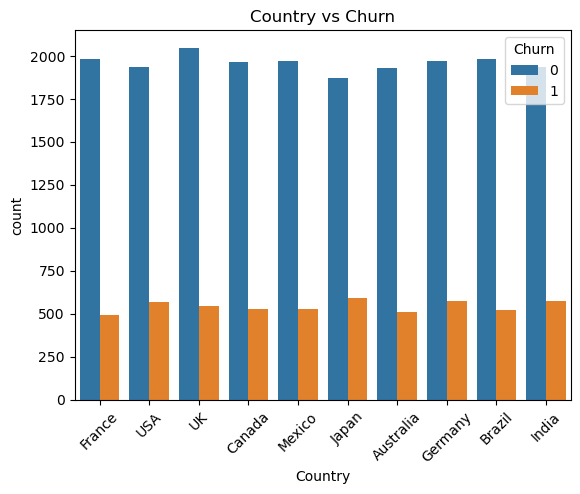

In [26]:
sns.countplot(x='Country', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title('Country vs Churn')
plt.show()


<h3><b> Correlation Heatmap</h3>

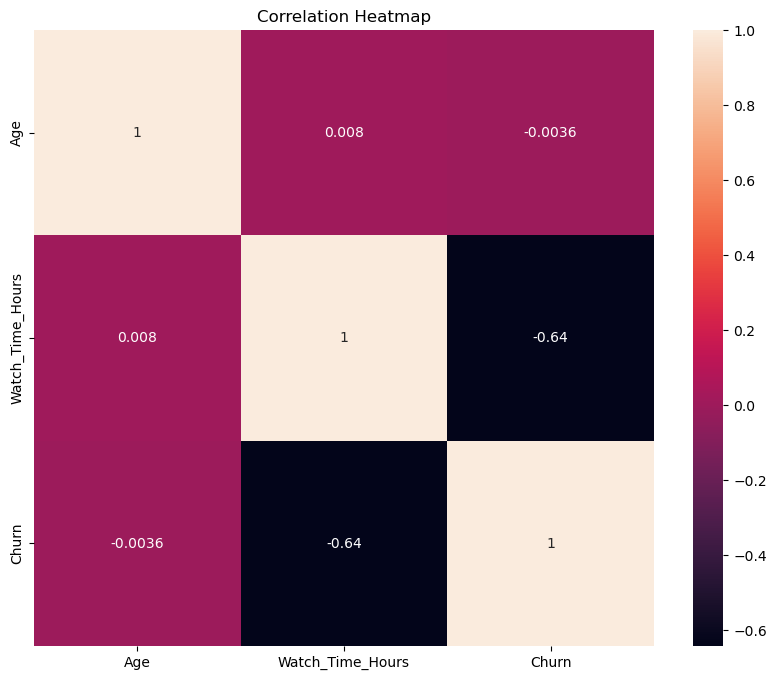

In [27]:
plt.figure(figsize=(10,8))
plt.title('Correlation Heatmap')
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [28]:
df.shape

(25000, 7)

In [ ]:
# Convert Last_Login to recency
df['Last_Login'] = pd.to_datetime(df['Last_Login'])
df['Last_Login_Recency'] = (pd.Timestamp.today() - df['Last_Login']).dt.days


<h3><b>6) Encoding</h3>

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le_country = LabelEncoder()
le_subscription = LabelEncoder()
le_genre = LabelEncoder()

In [30]:
df['Country_encoded'] = le_country.fit_transform(df['Country'])
df['Subscription_encoded'] = le_subscription.fit_transform(df['Subscription_Type'])
df['Genre_encoded'] = le_genre.fit_transform(df['Favorite_Genre'])

<h3><b>7) Feature Selection</h3>

In [32]:

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

print(X.head())

   Age  Watch_Time_Hours  Country_encoded  Subscription_encoded  \
0   18             80.26                3                     1   
1   23            321.75                9                     1   
2   60             35.89                8                     0   
3   44            261.56                9                     1   
4   68            909.30                9                     2   

   Genre_encoded  Country_Brazil  Country_Canada  Country_France  \
0              3           False           False            True   
1              6           False           False           False   
2              1           False           False           False   
3              2           False           False           False   
4              3           False           False           False   

   Country_Germany  Country_India  ...  Subscription_Type_Standard  \
0            False          False  ...                       False   
1            False          False  ...          

<h3><b>8) Train-Test Split</h3>

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for classification
)

<h3><b>9) Feature Scaling </h3>

<h3><b>10) Model Building & Training</h3>

In [42]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

<h3><b>11) Model Evaluation(Predictions)</h3>

In [43]:
y_pred = rf.predict(X_test)

<h3><b>i) Accuracy</h3>

In [44]:
print("Accuracy:", rf.score(X_test, y_test))

Accuracy: 0.9052


<h3><b>ii) Confusion Matrix</h3>

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3579  335]
 [ 139  947]]


<h3><b>iii) Classification Report</h3>

<h3><b>12) Improve Model</h3>

In [99]:
# Cross-validation
# Hyperparameter tuning

<h3><b>13) Save Model</h3>

In [47]:
import joblib
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [48]:
import os
print(os.getcwd())

C:\Users\alian


<h3><b>14) Model Deployment</h3>